<a href="https://colab.research.google.com/github/calistasalscpw/Selena-Finance-Tracker/blob/rismaul/Selena_App.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CAPSTONE PROJECT - SELENA APP (SELLING, FINANCE, AND ANALYTICS)**

## **Proses Analisis oleh Model ML (Menggunakan File .pkl)**

1. Backend memuat model ML yang sudah dilatih (disimpan dalam format .pkl) menggunakan library Pickle di Python.
2. Model ML ini memproses data transaksi pengguna yang sudah diambil dari database untuk melakukan beberapa tugas analisis:
  - Deteksi Anomali Pengeluaran: Model ML mendeteksi adanya transaksi atau pengeluaran yang tidak biasa atau mencurigakan.
  - Arus Kas: Mengidentifikasi pola pemasukan dan pengeluaran.
  - Saran Keuangan: Berdasarkan analisis tren keuangan pengguna, model bisa memberikan saran, misalnya mengurangi pengeluaran di kategori tertentu.

## **Pengembalian Hasil Analisis ke Backend (ML ke CC)**

1. Model ML menghasilkan output analisis, seperti rekomendasi keuangan dan deteksi anomali, yang dikonversi ke format JSON.
2. Backend menerima hasil ini dan menggabungkannya menjadi satu respons JSON yang siap dikirim ke aplikasi mobile.

In [1]:
import csv
import pickle
import numpy as np
import pandas as pd

### **Convert Excel to CSV**

In [2]:
#read_file = pd.read_excel("Order.completed.20240903_20241003.xlsx")
#read_file.to_csv("Order.completed.20240903_20241003.csv", header=True)
#df = pd.read_csv("Order.completed.20240903_20241003.csv")

In [3]:
#from google.colab import data_table
#data_table.DataTable(df)

### **Assessing Data**

In [4]:
#def assessing_data(df):
#    print(f"\n---TABLE INFO---\n")
#    df.info()

#    print(f"\n---MISSING VALUES---\n")
#    print(df.isna().sum())

#    print(f"\n---DUPLICATE DATA---\n")
#    print(df.duplicated().sum())

#    print(f"\n---STATISTICS PARAMETER---\n")
#    print(df.describe())

In [5]:
#assessing_data(df)

### **Pre-processing Data**

In [6]:
from sklearn.preprocessing import MinMaxScaler

#Min-Max Scaler Initialization
scaler = MinMaxScaler(feature_range=(0, 1))

In [7]:
#FUNGSI UNTUK PREPROCESSING DATA

def preprocess_data(data):

    # Membaca file dataset
    read_file = pd.read_excel(data)
    read_file.to_csv("dataset.csv", header=True)
    df = pd.DataFrame(pd.read_csv("dataset.csv"))

    # Mengganti nama kolom
    data_filtered = df.rename(columns={'Jumlah Produk di Pesan': 'Jumlah Pemesanan'}, inplace=True)

    # Mengambil kolom yang dibutuhkan
    data_filtered = df[['Jumlah Pemesanan', 'Total Pembayaran', 'Waktu Pesanan Selesai']].copy()

    # Menghapus titik dari kolom 'Total Pembayaran'
    data_filtered['Total Pembayaran'] = data_filtered['Total Pembayaran'].astype(str).str.replace('.', '', regex=False)

    # Mengkonversi tipe data
    data_filtered['Total Pembayaran'] = pd.to_numeric(data_filtered['Total Pembayaran'])
    data_filtered['Waktu Pesanan Selesai'] = pd.to_datetime(data_filtered['Waktu Pesanan Selesai']).dt.date

    # Menghapus pesanan yang dibatalkan/tidak selesai
    data_final = data_filtered[data_filtered['Total Pembayaran'] != 0]
    data_final[['Total Pembayaran']] = scaler.fit_transform(data_final[['Total Pembayaran']])

    # Assign value variabel time dan series
    time = data_final['Waktu Pesanan Selesai'].tolist()
    series = data_final['Total Pembayaran'].tolist()

    return time, series

## **TIME SERIES**

In [8]:
DATA_PATH = 'Order.completed.20240903_20241003.xlsx'
TIME, SERIES = preprocess_data(DATA_PATH)

<ipython-input-7-6e5595482796>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final[['Total Pembayaran']] = scaler.fit_transform(data_final[['Total Pembayaran']])


In [9]:
# Global Variables
SPLIT_TIME = 50
WINDOW_SIZE = 16
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 75

### **Defining Function**

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

In [11]:
def plot_series(time, series, format="-", start=0, end=None):

    plt.figure(figsize=(30, 6))
    plt.plot(time[start:end], series[start:end], format)
    plt.xlabel("Date")
    plt.ylabel("Income")
    plt.grid(True)
    plt.gca().xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))  # Menyesuaikan format tanggal
    plt.gcf().autofmt_xdate()  # Memutar tanggal agar tidak bertabrakan
    plt.show()

In [12]:
def train_val_split(time, series):

    time_train = time[:SPLIT_TIME]
    series_train = series[:SPLIT_TIME]
    time_valid = time[SPLIT_TIME:]
    series_valid = series[SPLIT_TIME:]

    return time_train, series_train, time_valid, series_valid

In [13]:
def windowed_dataset(series, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, shuffle_buffer=SHUFFLE_BUFFER_SIZE):

    # Konversi data series ke dalam dataset tensorflow
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Membuat window untuk setiap sample
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)

    # Konversi setiap window ke dalam bentuk batch
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    # Memisahkan window menjadi input (features) dan output (label)
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))

    # Mengacak data menggunakan shuffle buffer
    dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    # Membuat batch data
    dataset = dataset.batch(batch_size).prefetch(1)

    return dataset

In [14]:
def create_uncompiled_model():

    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=(WINDOW_SIZE, 1)),
        tf.keras.layers.Conv1D(filters=32, kernel_size=3, strides=1, padding='causal', activation='relu'),
        tf.keras.layers.LSTM(16, return_sequences=True, dropout=0.2),
        tf.keras.layers.LSTM(8, dropout=0.2),
        tf.keras.layers.Dense(4, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

    return model

In [15]:
def create_model():

    model = create_uncompiled_model()

    model.compile(loss = tf.keras.losses.Huber(),
                  optimizer = tf.keras.optimizers.Adam(),
                  metrics=["mae"])

    return model

### **Plot Series**

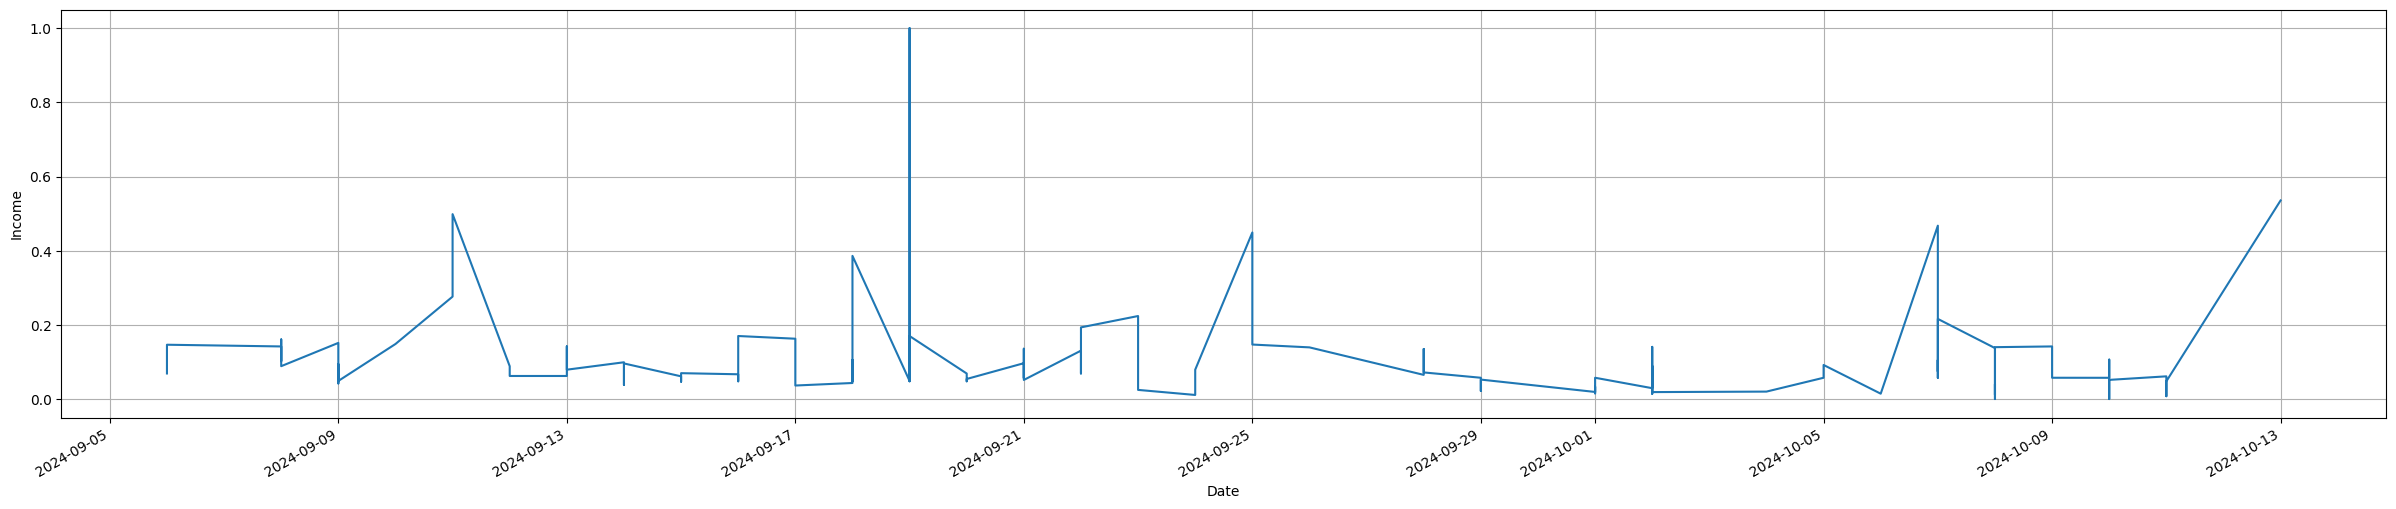

In [16]:
plot_series(TIME, SERIES)

In [17]:
# Split the dataset
time_train, series_train, time_valid, series_valid = train_val_split(TIME, SERIES)

# Apply the transformation to the training set
series_train_windowed = windowed_dataset(series_train)
series_valid_windowed = windowed_dataset(series_valid)

In [18]:
# Get your uncompiled model
uncompiled_model = create_uncompiled_model()

In [19]:
uncompiled_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 16, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 16, 16)              │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 8)                   │             800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,105 (16.04 KB)

 Trainable params: 4,105 (16.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
example_batch = series_train_windowed.take(1)

try:
	predictions = uncompiled_model.predict(example_batch, verbose=False)
except:
	print("Your model is not compatible with the dataset you defined earlier. Check that the loss function and last layer are compatible with one another.")
else:
	print("Your current architecture is compatible with the windowed dataset! :)")
	print(f"predictions have shape: {predictions.shape}")

Your current architecture is compatible with the windowed dataset! :)
predictions have shape: (32, 1)


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [21]:
# Get your model
model = create_model()

In [22]:
lr_schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch / 20))

history = model.fit(series_train_windowed, validation_data=series_valid_windowed, epochs=100, callbacks=[lr_schedule])

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 550ms/step - loss: 0.0159 - mae: 0.0762 - val_loss: 0.0063 - val_mae: 0.0587 - learning_rate: 1.0000e-04
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0169 - mae: 0.0801 - val_loss: 0.0061 - val_mae: 0.0583 - learning_rate: 1.1220e-04
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0169 - mae: 0.0709 - val_loss: 0.0060 - val_mae: 0.0579 - learning_rate: 1.2589e-04
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0165 - mae: 0.0826 - val_loss: 0.0059 - val_mae: 0.0576 - learning_rate: 1.4125e-04
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0162 - mae: 0.0822 - val_loss: 0.0058 - val_mae: 0.0574 - learning_rate: 1.5849e-04
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0160 - mae: 0.0832 - val_loss: 0.0058 - val_mae: 0.0580 - learning_rate: 1.7783e-04
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0148 - mae: 0.0755 - val_loss: 0.0057 - val_mae: 0.0591 - learning_rate: 1.

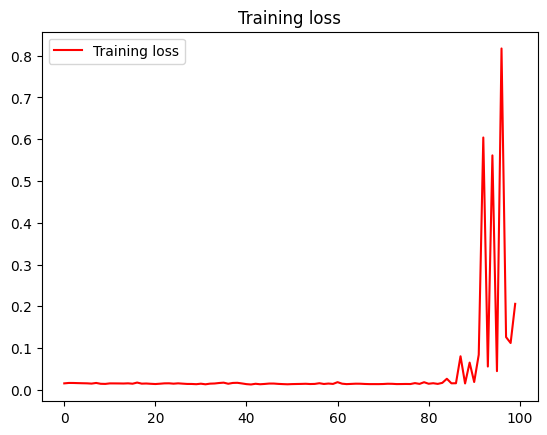

In [23]:
# Plot the training loss for each epoch

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))

plt.plot(epochs, loss, 'r', label='Training loss')
plt.title('Training loss')
plt.legend(loc=0)
plt.show()

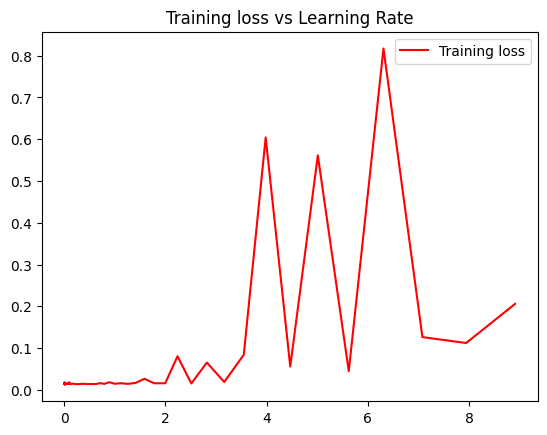

In [24]:
# Plot the training loss for each learning rate

lr = history.history['learning_rate']

plt.plot(lr, loss, 'r', label='Training loss')
plt.title('Training loss vs Learning Rate')
plt.legend(loc=0)
plt.show()

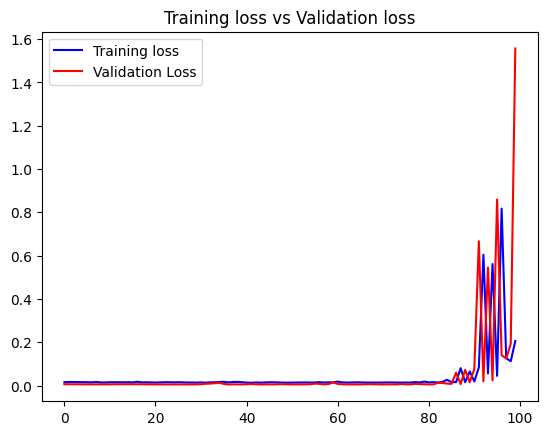

In [25]:
# Plot the training loss for each learning rate

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training loss vs Validation loss')
plt.legend()
plt.show()

### **Evaluate Forecast**

In [26]:
def compute_metrics(true_series, forecast):

    mse = tf.keras.losses.MSE(true_series, forecast)
    mae = tf.keras.losses.MAE(true_series, forecast)
    return mse, mae

In [27]:
def model_forecast(model, series, window_size):

    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size))
    ds = ds.batch(32).prefetch(1)
    forecast = model.predict(ds)
    return forecast

In [28]:
# Compute the forecast for the validation dataset. Remember you need the last WINDOW SIZE values to make the first prediction
rnn_forecast = model_forecast(model, SERIES[SPLIT_TIME-WINDOW_SIZE:-1], WINDOW_SIZE).squeeze()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step


<Figure size 3000x600 with 0 Axes>

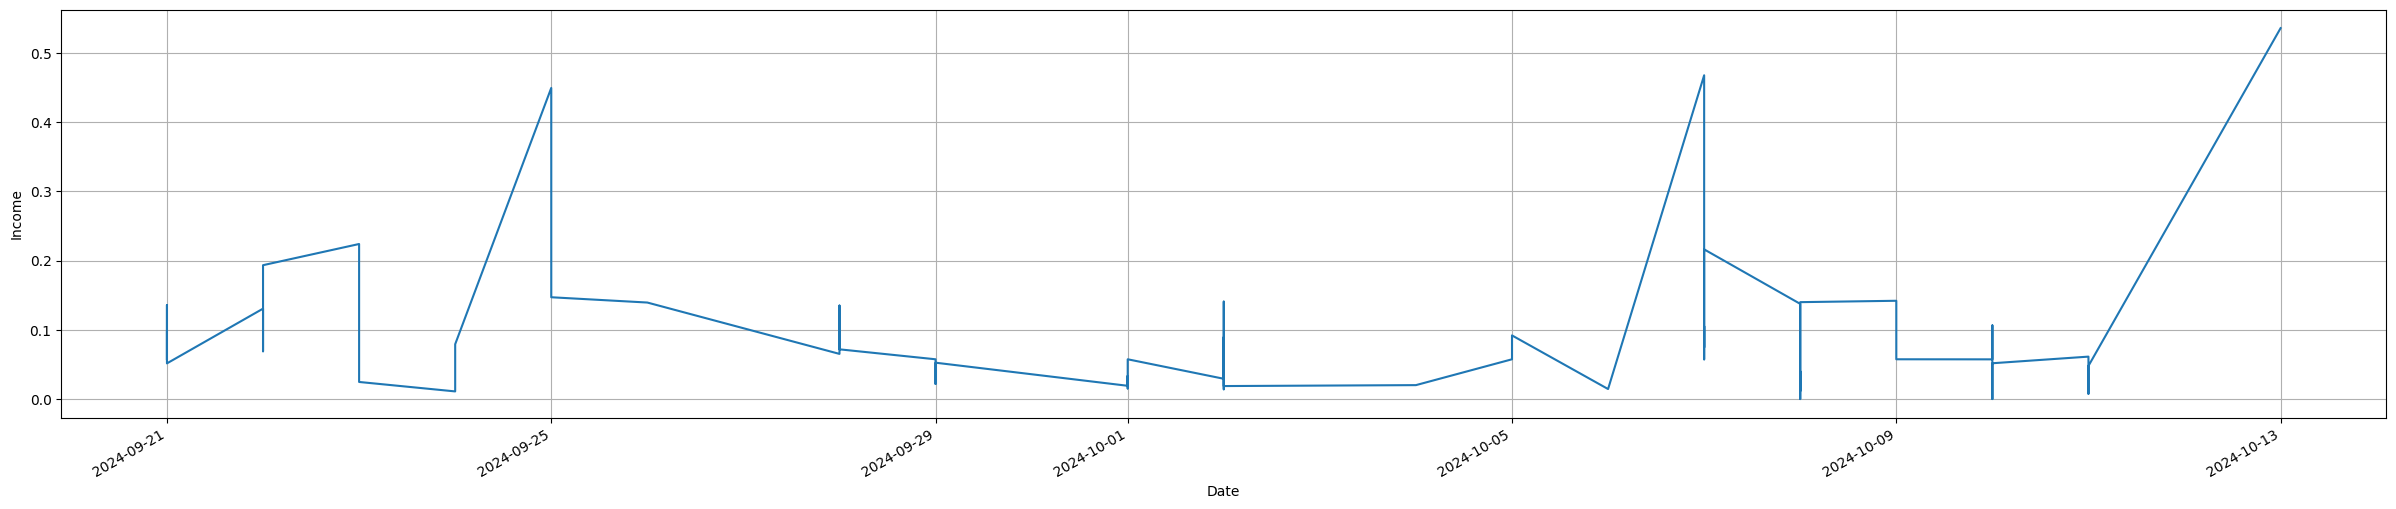

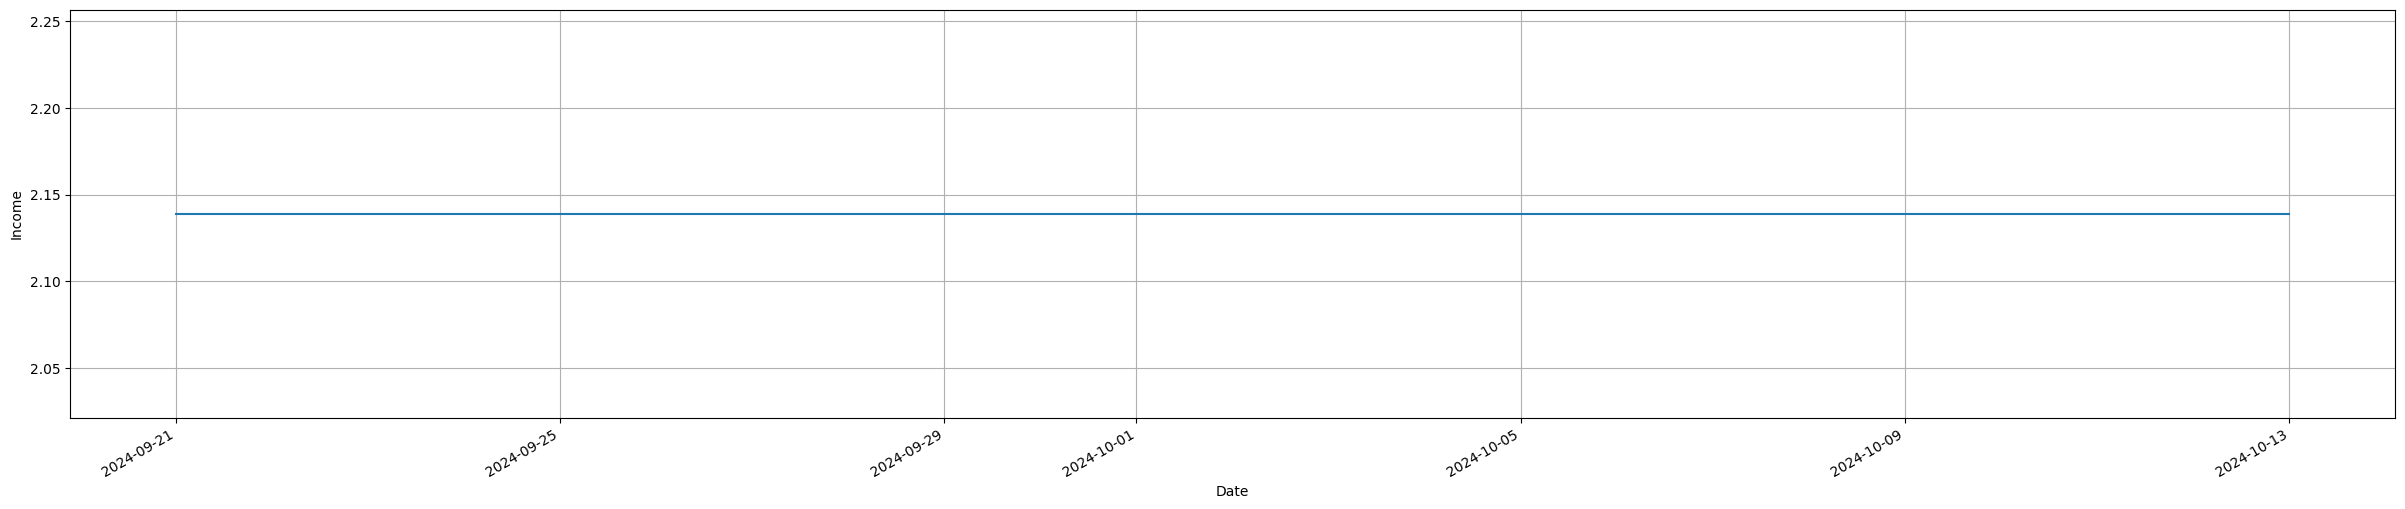

In [29]:
# Plot the forecast
plt.figure(figsize=(30, 6))
plot_series(time_valid, series_valid)
plot_series(time_valid, rnn_forecast)

In [30]:
mse, mae = compute_metrics(series_valid, rnn_forecast)

print(f"mse: {mse:.2f}, mae: {mae:.2f} for forecast")

mse: 4.20, mae: 2.05 for forecast
